# Historical Sites per County

Builds a county-level variable: number of National Register of Historic Places (NRHP) sites in each county, from the National Register's own listing export. Run against the real NRHP dataset.

### Load real NRHP data and count sites per county

In [1]:
import numpy as np
import pandas as pd 


#Create a variable for the number of historical sites in each county.
#Use the national register of historic places data, which has a column for county.
#All counties will be incuded in the data set, even those not in the DC file

path = 'Distance_to_variables/national-register-listed_20250624.xlsx'
nrhp = pd.read_excel(path)  
print(nrhp.columns)
nrhp_counties = nrhp.groupby(["State", "County"]).size().reset_index(name='Historical_Sites')
print(nrhp_counties.head())
nrhp_counties.to_csv('Distance_to_variables/nrhp_by_county.csv', index=False)  

Index(['Ref#', 'Prefix', 'Property Name', 'State', 'County', 'City ',
       'Street & Number', 'Status', 'Request Type', 'Restricted Address',
       'Acreage of Property', 'Area of Significance', 'Category of Property',
       'External Link', 'Level of Significance - International',
       'Level of Significance - Local', 'Level of Significance - National',
       'Level of Significance - Not Indicated',
       'Level of Significance - State', 'Listed Date',
       'Name of Multiple Property Listing', 'NHL Designated Date',
       'Other Names', 'Park Name', 'Property ID'],
      dtype='str')
     State   County  Historical_Sites
0  ALABAMA  Autauga                 5
1  ALABAMA  Baldwin                68
2  ALABAMA  Barbour                20
3  ALABAMA     Bibb                 6
4  ALABAMA   Blount                 5


## Visualization

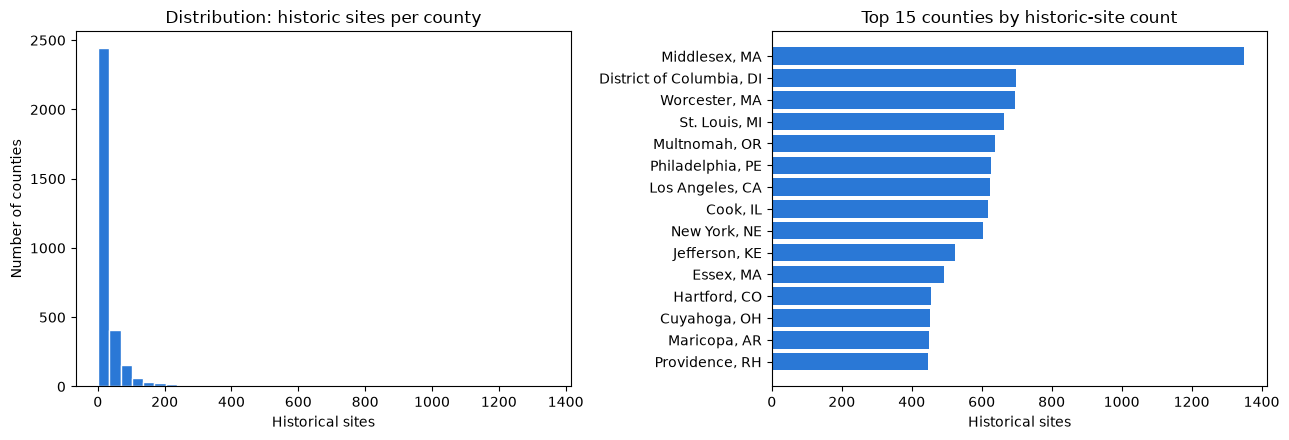

In [2]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pandas as pd
df = pd.read_csv("Distance_to_variables/nrhp_by_county.csv")

top15 = df.sort_values("Historical_Sites", ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["Historical_Sites"], bins=40, color="#2a78d6", edgecolor="white")
axes[0].set_title("Distribution: historic sites per county")
axes[0].set_xlabel("Historical sites")
axes[0].set_ylabel("Number of counties")

axes[1].barh(top15["County"] + ", " + top15["State"].str[:2], top15["Historical_Sites"], color="#2a78d6")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 counties by historic-site count")
axes[1].set_xlabel("Historical sites")

plt.tight_layout()
plt.show()
